<a href="https://colab.research.google.com/github/arasorietnom/RFM-CLV-analysis-with-PCA-clustering/blob/main/Market_Research_Behavioral_Fashion_Customer_Segmentation_(RFM%2CCLV%2CPCA%2CKMeans)_code_only.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import

In [ ]:
#IF jupyter notebook or VS

!pip install scikit-learn tabulate plotly pandas seaborn matplotlib numpy scipy

In [ ]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import plotly.graph_objects as go

# Machine Learning and Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.stats import linregress

# Clustering Evaluation and Visualization
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# Utilities
from collections import Counter
from tabulate import tabulate
from google.colab import files

# Data-Preprocessing: Import, Merge and Manage Dataframes

In [ ]:
# Load the Orders Excel file
orders_file = pd.ExcelFile('/content/Orders2.0.xlsx')

In [ ]:
# Display sheet names to understand what we're working with
sheet_names = orders_file.sheet_names
print(sheet_names)

['scanner_data', 'product description ']


In [ ]:
# Load the two sheets into separate DataFrames
scanner_data_df = pd.read_excel(orders_file, sheet_name='scanner_data')
product_description_df = pd.read_excel(orders_file, sheet_name='product description ')

In [ ]:
# Display the first few rows of each dataframe to understand their structure
scanner_data_df.head(), product_description_df.head()

(   id       Date  Customer_ID  Transaction_ID SKU_Category    SKU  Quantity  \
 0   1 2021-01-02         2547               1          X52  0EM7L       1.0   
 1   2 2021-01-02          822               2          2ML  68BRQ       1.0   
 2   3 2021-01-02         3686               3          0H2  CZUZX       1.0   
 3   4 2021-01-02         3719               4          0H2  549KK       1.0   
 4   5 2021-01-02         9200               5          0H2  K8EHH       1.0   
 
    Sales_Amount  
 0          3.13  
 1          5.46  
 2          6.35  
 3          5.59  
 4          6.88  ,
   SKU_Category    SKU                                       description 
 0          X52  0EM7L  U.S. Polo Assn. Kids Girls Pink & Blue Printed...
 1          2ML  68BRQ  W Women Off-White & Charcoal Grey Printed Stra...
 2          0H2  CZUZX    Studio Voylla Gold-Toned & Green Square Jhumkas
 3          0H2  549KK  Roadster Women Black Skinny Fit Mid-Rise Mildl...
 4          0H2  K8EHH  AURELIA W

In [ ]:
# Perform an inner join on the two DataFrames using 'SKU' and 'SKU_Category' as keys
merged_df = pd.merge(scanner_data_df, product_description_df, on=['SKU', 'SKU_Category'], how='inner')


merged_df.head()


,id,Date,Customer_ID,Transaction_ID,SKU_Category,SKU,Quantity,Sales_Amount,description
0,1,2021-01-02,2547,1,X52,0EM7L,1.0,3.13,U.S. Polo Assn. Kids Girls Pink & Blue Printed...
1,627,2021-01-04,289,325,X52,0EM7L,1.0,3.13,U.S. Polo Assn. Kids Girls Pink & Blue Printed...
2,4264,2021-01-14,8283,2018,X52,0EM7L,1.0,3.13,U.S. Polo Assn. Kids Girls Pink & Blue Printed...
3,5200,2021-01-17,3451,2472,X52,0EM7L,1.0,3.13,U.S. Polo Assn. Kids Girls Pink & Blue Printed...
4,8218,2021-01-26,6569,3942,X52,0EM7L,1.0,3.13,U.S. Polo Assn. Kids Girls Pink & Blue Printed...


In [ ]:
# Load the Customers data
customers_df = pd.read_excel('/content/Customers.xlsx')
customers_df.head()

,Customer_ID,GENDER,AGE,GEOGRAPHY
0,2547,M,43,Greece
1,822,M,42,Spain
2,3686,F,39,France
3,3719,F,30,Italy
4,9200,F,31,Italy


Inner join

In [ ]:
# Perform an inner join on the merged DataFrame and the Customer data using 'Customer_ID' as the key
final_merged_df = pd.merge(merged_df, customers_df, on='Customer_ID', how='inner')

# Display the first few rows of the final merged dataframe
final_merged_df.head()


,id,Date,Customer_ID,Transaction_ID,SKU_Category,SKU,Quantity,Sales_Amount,description,GENDER,AGE,GEOGRAPHY
0,1,2021-01-02,2547,1,X52,0EM7L,1.0,3.13,U.S. Polo Assn. Kids Girls Pink & Blue Printed...,M,43,Greece
1,37202,2021-04-16,2547,18247,TVL,6ASJR,1.0,6.00,Roadster Women Navy Blue Striped Mandarin Coll...,M,43,Greece
2,27608,2021-03-21,2547,13396,N8U,UQC6F,3.0,5.32,FAUSTO Women Pink Sneakers,M,43,Greece
3,34932,2021-04-11,2547,17148,N8U,UQC6F,3.0,5.32,FAUSTO Women Pink Sneakers,M,43,Greece
4,34934,2021-04-11,2547,17148,P42,6RXA9,1.0,5.62,Moedbuille Women Pink & Greman Silver Necklace,M,43,Greece


# **Data Cleaning**



In [ ]:
final_merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131706 entries, 0 to 131705
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   id              131706 non-null  int64         
 1   Date            131706 non-null  datetime64[ns]
 2   Customer_ID     131706 non-null  int64         
 3   Transaction_ID  131706 non-null  int64         
 4   SKU_Category    131706 non-null  object        
 5   SKU             131706 non-null  object        
 6   Quantity        131706 non-null  float64       
 7   Sales_Amount    131706 non-null  float64       
 8   description     131706 non-null  object        
 9   GENDER          131706 non-null  object        
 10  AGE             131706 non-null  int64         
 11  GEOGRAPHY       131706 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(5)
memory usage: 12.1+ MB


In [ ]:
final_merged_df.describe()

,id,Date,Customer_ID,Transaction_ID,Quantity,Sales_Amount,AGE
count,131706.000000,131706,131706.000000,131706.000000,131706.000000,131706.000000,131706.000000
mean,65853.500000,2021-07-04 21:39:26.379663616,12386.450367,32389.604187,1.485318,11.981524,35.423823
min,1.000000,2021-01-02 00:00:00,1.000000,1.000000,0.010000,0.020000,18.000000
25%,32927.250000,2021-04-05 00:00:00,7349.000000,16134.000000,1.000000,4.230000,31.000000
50%,65853.500000,2021-07-02 00:00:00,13496.000000,32620.000000,1.000000,6.920000,36.000000
75%,98779.750000,2021-10-07 00:00:00,17306.000000,48548.000000,1.000000,12.330000,40.000000
max,131706.000000,2021-12-31 00:00:00,22625.000000,64682.000000,400.000000,707.730000,62.000000
std,38020.391614,NaN,6086.447552,18709.901238,3.872666,19.359699,7.064370


In [ ]:
duplicate_rows = final_merged_df.duplicated()

# Remove duplicates
final_merged_df_cleaned = final_merged_df[~duplicate_rows]

# Count of removed duplicates
duplicates_removed = duplicate_rows.sum()

duplicates_removed, final_merged_df_cleaned.shape


(0, (131706, 12))

In [ ]:
negative_sales = final_merged_df_cleaned[final_merged_df_cleaned['Sales_Amount'] < 0]

negative_sales_count = negative_sales.shape[0]
negative_sales_count


0

In [ ]:
df1 = final_merged_df_cleaned

In [ ]:
print(df1.head())

      id       Date  Customer_ID  Transaction_ID SKU_Category    SKU  \
0      1 2021-01-02         2547               1          X52  0EM7L   
1  37202 2021-04-16         2547           18247          TVL  6ASJR   
2  27608 2021-03-21         2547           13396          N8U  UQC6F   
3  34932 2021-04-11         2547           17148          N8U  UQC6F   
4  34934 2021-04-11         2547           17148          P42  6RXA9   

   Quantity  Sales_Amount                                       description   \
0       1.0          3.13  U.S. Polo Assn. Kids Girls Pink & Blue Printed...   
1       1.0          6.00  Roadster Women Navy Blue Striped Mandarin Coll...   
2       3.0          5.32                         FAUSTO Women Pink Sneakers   
3       3.0          5.32                         FAUSTO Women Pink Sneakers   
4       1.0          5.62     Moedbuille Women Pink & Greman Silver Necklace   

  GENDER  AGE GEOGRAPHY  
0      M   43    Greece  
1      M   43    Greece  
2      M

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131706 entries, 0 to 131705
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   id              131706 non-null  int64         
 1   Date            131706 non-null  datetime64[ns]
 2   Customer_ID     131706 non-null  int64         
 3   Transaction_ID  131706 non-null  int64         
 4   SKU_Category    131706 non-null  object        
 5   SKU             131706 non-null  object        
 6   Quantity        131706 non-null  float64       
 7   Sales_Amount    131706 non-null  float64       
 8   description     131706 non-null  object        
 9   GENDER          131706 non-null  object        
 10  AGE             131706 non-null  int64         
 11  GEOGRAPHY       131706 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(5)
memory usage: 12.1+ MB


In [ ]:
# Summary statistics for numerical variables
df1.describe().T

,count,mean,min,25%,50%,75%,max,std
id,131706.0,65853.5,1.0,32927.25,65853.5,98779.75,131706.0,38020.391614
Date,131706,2021-07-04 21:39:26.379663616,2021-01-02 00:00:00,2021-04-05 00:00:00,2021-07-02 00:00:00,2021-10-07 00:00:00,2021-12-31 00:00:00,NaN
Customer_ID,131706.0,12386.450367,1.0,7349.0,13496.0,17306.0,22625.0,6086.447552
Transaction_ID,131706.0,32389.604187,1.0,16134.0,32620.0,48548.0,64682.0,18709.901238
Quantity,131706.0,1.485318,0.01,1.0,1.0,1.0,400.0,3.872666
Sales_Amount,131706.0,11.981524,0.02,4.23,6.92,12.33,707.73,19.359699
AGE,131706.0,35.423823,18.0,31.0,36.0,40.0,62.0,7.06437


In [ ]:
# Summary statistics for categorical variables
df1.describe(include='object').T

,count,unique,top,freq
SKU_Category,131706,187,N8U,10913
SKU,131706,5242,UNJKW,2007
description,131706,5242,GNIST Women Pink Solid Heels,2007
GENDER,131706,2,F,73136
GEOGRAPHY,131706,7,Germany,37959


# Unique stock codes

In [ ]:
# Finding the number of unique stock codes
unique_stock_codes = df1['SKU'].nunique()

# Printing the number of unique stock codes
print(f"The number of unique stock codes in the dataset is: {unique_stock_codes}")

The number of unique stock codes in the dataset is: 5242


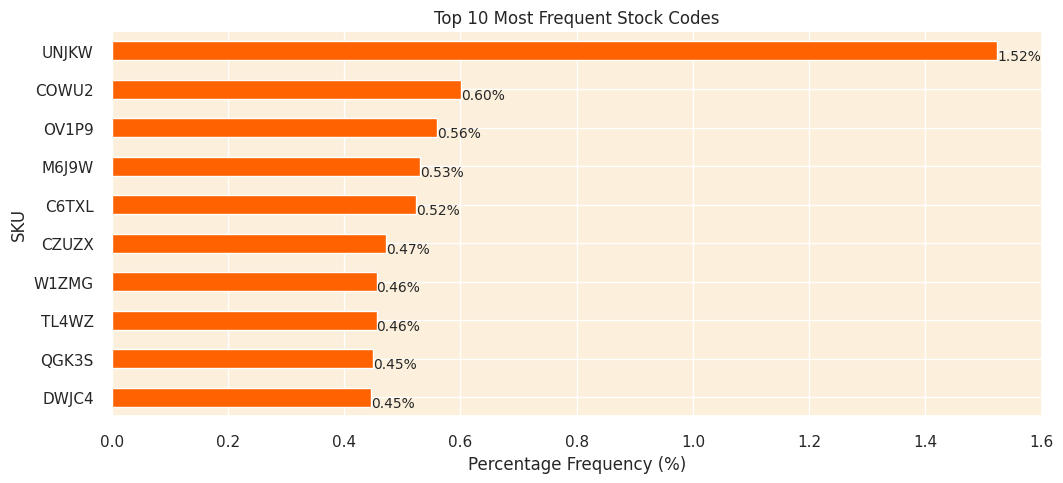

In [ ]:
# Finding the top 10 most frequent stock codes
top_10_stock_codes = df1['SKU'].value_counts(normalize=True).head(10) * 100

# Plotting the top 10 most frequent stock codes
plt.figure(figsize=(12, 5))
top_10_stock_codes.plot(kind='barh', color='#ff6200')

# Adding the percentage frequency on the bars
for index, value in enumerate(top_10_stock_codes):
    plt.text(value, index+0.25, f'{value:.2f}%', fontsize=10)

plt.title('Top 10 Most Frequent Stock Codes')
plt.xlabel('Percentage Frequency (%)')
plt.ylabel('SKU')
plt.gca().invert_yaxis()
plt.show()

# **RFM Analysis**

# Recency (R)

In [ ]:
# Convert Date to datetime type
df1['Date'] = pd.to_datetime(df1['Date'])

# Convert Date to datetime and extract only the date
df1['Day'] = df1['Date'].dt.date

# Find the most recent purchase date for each customer
customer_data = df1.groupby('Customer_ID')['Day'].max().reset_index()

# Find the most recent date in the entire dataset
most_recent_date = df1['Day'].max()

# Convert Day to datetime type before subtraction
customer_data['Day'] = pd.to_datetime(customer_data['Day'])
most_recent_date = pd.to_datetime(most_recent_date)

# Calculate the number of days since the last purchase for each customer
customer_data['Days_Since_Last_Purchase'] = (most_recent_date - customer_data['Day']).dt.days

# Remove the Day column
customer_data.drop(columns=['Day'], inplace=True)

Now, customer_data dataframe contains the Days_Since_Last_Purchase feature:

In [ ]:
customer_data.head()

,Customer_ID,Days_Since_Last_Purchase
0,1,343
1,2,195
2,3,363
3,4,52
4,5,179


Note:
I've named the customer-centric dataframe as customer_data, which will eventually contain all the customer-based features we plan to create.

# Frequency (F)

In [ ]:
# Calculate the total number of transactions made by each customer
total_transactions = df1.groupby('Customer_ID')['Transaction_ID'].nunique().reset_index()
total_transactions.rename(columns={'Transaction_ID': 'Total_Transactions'}, inplace=True)

# Calculate the total number of products purchased by each customer
total_products_purchased = df1.groupby('Customer_ID')['Quantity'].sum().reset_index()
total_products_purchased.rename(columns={'Quantity': 'Total_Products_Purchased'}, inplace=True)

# Merge the new features into the customer_data dataframe
customer_data = pd.merge(customer_data, total_transactions, on='Customer_ID')
customer_data = pd.merge(customer_data, total_products_purchased, on='Customer_ID')

# Display the first few rows of the customer_data dataframe
customer_data.head()

,Customer_ID,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased
0,1,343,1,2.0
1,2,195,2,2.0
2,3,363,1,4.0
3,4,52,2,5.0
4,5,179,5,14.0


# Monetary (M)

In [ ]:
# Calculate the total spend by each customer
df1['Total_Spend'] = df1['Sales_Amount'] * df1['Quantity']
total_spend = df1.groupby('Customer_ID')['Total_Spend'].sum().reset_index()

# Calculate the average transaction value for each customer
average_transaction_value = total_spend.merge(total_transactions, on='Customer_ID')
average_transaction_value['Average_Transaction_Value'] = average_transaction_value['Total_Spend'] / average_transaction_value['Total_Transactions']

# Merge the new features into the customer_data dataframe
customer_data = pd.merge(customer_data, total_spend, on='Customer_ID')
customer_data = pd.merge(customer_data, average_transaction_value[['Customer_ID', 'Average_Transaction_Value']], on='Customer_ID')

# Display the first few rows of the customer_data dataframe
customer_data.head()

,Customer_ID,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value
0,1,343,1,2.0,16.29,16.290
1,2,195,2,2.0,22.77,11.385
2,3,363,1,4.0,19.08,19.080
3,4,52,2,5.0,33.29,16.645
4,5,179,5,14.0,248.27,49.654


# Product Diversity

In [ ]:
# Calculate the number of unique products purchased by each customer
unique_products_purchased = df1.groupby('Customer_ID')['SKU'].nunique().reset_index()
unique_products_purchased.rename(columns={'SKU': 'Unique_Products_Purchased'}, inplace=True)

# Merge the new feature into the customer_data dataframe
customer_data = pd.merge(customer_data, unique_products_purchased, on='Customer_ID')

# Display the first few rows of the customer_data dataframe
customer_data.head()

,Customer_ID,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased
0,1,343,1,2.0,16.29,16.290,2
1,2,195,2,2.0,22.77,11.385,2
2,3,363,1,4.0,19.08,19.080,3
3,4,52,2,5.0,33.29,16.645,5
4,5,179,5,14.0,248.27,49.654,2


# Behavioral Features

In [ ]:
# Extract day of week and hour from Date
df1['Day_Of_Week'] = df1['Date'].dt.dayofweek
df1['Hour'] = df1['Date'].dt.hour

# Calculate the average number of days between consecutive purchases
days_between_purchases = df1.groupby('Customer_ID')['Day'].apply(lambda x: (x.diff().dropna()).apply(lambda y: y.days))
average_days_between_purchases = days_between_purchases.groupby('Customer_ID').mean().reset_index()
average_days_between_purchases.rename(columns={'Day': 'Average_Days_Between_Purchases'}, inplace=True)

# Find the favorite shopping day of the week
favorite_shopping_day = df1.groupby(['Customer_ID', 'Day_Of_Week']).size().reset_index(name='Count')
favorite_shopping_day = favorite_shopping_day.loc[favorite_shopping_day.groupby('Customer_ID')['Count'].idxmax()][['Customer_ID', 'Day_Of_Week']]

# Find the favorite shopping hour of the day
favorite_shopping_hour = df1.groupby(['Customer_ID', 'Hour']).size().reset_index(name='Count')
favorite_shopping_hour = favorite_shopping_hour.loc[favorite_shopping_hour.groupby('Customer_ID')['Count'].idxmax()][['Customer_ID', 'Hour']]

# Merge the new features into the customer_data dataframe
customer_data = pd.merge(customer_data, average_days_between_purchases, on='Customer_ID')
customer_data = pd.merge(customer_data, favorite_shopping_day, on='Customer_ID')
customer_data = pd.merge(customer_data, favorite_shopping_hour, on='Customer_ID')

# Display the first few rows of the customer_data dataframe
customer_data.head()

<ipython-input-98-2f3d8f180d65>:6: FutureWarning:

The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.



,Customer_ID,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour
0,1,343,1,2.0,16.29,16.290,2,0.0,4,0
1,2,195,2,2.0,22.77,11.385,2,87.0,2,0
2,3,363,1,4.0,19.08,19.080,3,0.0,5,0
3,4,52,2,5.0,33.29,16.645,5,0.0,1,0
4,5,179,5,14.0,248.27,49.654,2,36.5,0,0


# Geographic Features

In [ ]:
df1['GEOGRAPHY'].value_counts(normalize=True).head()

,proportion
GEOGRAPHY,
Germany,0.288210
Italy,0.259047
France,0.168960
Greece,0.097368
Spain,0.076443


In [ ]:
# Group by Customer_ID and Country to get the number of transactions per country for each customer
customer_country = df1.groupby(['Customer_ID', 'GEOGRAPHY']).size().reset_index(name='Number_of_Transactions')

# Get the country with the maximum number of transactions for each customer (in case a customer has transactions from multiple countries)
customer_main_country = customer_country.sort_values('Number_of_Transactions', ascending=False).drop_duplicates('Customer_ID')

# Merge this data with our customer_data dataframe
customer_data = pd.merge(customer_data, customer_main_country[['Customer_ID','GEOGRAPHY']], on='Customer_ID', how='left')

# Display the first few rows of the customer_data dataframe
customer_data.head()

,Customer_ID,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour,GEOGRAPHY
0,1,343,1,2.0,16.29,16.290,2,0.0,4,0,UK
1,2,195,2,2.0,22.77,11.385,2,87.0,2,0,Germany
2,3,363,1,4.0,19.08,19.080,3,0.0,5,0,UK
3,4,52,2,5.0,33.29,16.645,5,0.0,1,0,UK
4,5,179,5,14.0,248.27,49.654,2,36.5,0,0,Germany


# Seasonality & Trends

In [ ]:
# Extract month and year from InvoiceDate
df1['Year'] = df1['Date'].dt.year
df1['Month'] = df1['Date'].dt.month

# Calculate monthly spending for each customer
monthly_spending = df1.groupby(['Customer_ID', 'Year', 'Month'])['Total_Spend'].sum().reset_index()

# Calculate Seasonal Buying Patterns: We are using monthly frequency as a proxy for seasonal buying patterns
seasonal_buying_patterns = monthly_spending.groupby('Customer_ID')['Total_Spend'].agg(['mean', 'std']).reset_index()
seasonal_buying_patterns.rename(columns={'mean': 'Monthly_Spending_Mean', 'std': 'Monthly_Spending_Std'}, inplace=True)

# Replace NaN values in Monthly_Spending_Std with 0, implying no variability for customers with single transaction month
seasonal_buying_patterns['Monthly_Spending_Std'].fillna(0, inplace=True)

# Calculate Trends in Spending
# We are using the slope of the linear trend line fitted to the customer's spending over time as an indicator of spending trends
def calculate_trend(spend_data):
    # If there are more than one data points, we calculate the trend using linear regression
    if len(spend_data) > 1:
        x = np.arange(len(spend_data))
        slope, _, _, _, _ = linregress(x, spend_data)
        return slope
    # If there is only one data point, no trend can be calculated, hence we return 0
    else:
        return 0

# Apply the calculate_trend function to find the spending trend for each customer
spending_trends = monthly_spending.groupby('Customer_ID')['Total_Spend'].apply(calculate_trend).reset_index()
spending_trends.rename(columns={'Total_Spend': 'Spending_Trend'}, inplace=True)

# Merge the new features into the customer_data dataframe
customer_data = pd.merge(customer_data, seasonal_buying_patterns, on='Customer_ID')
customer_data = pd.merge(customer_data, spending_trends, on='Customer_ID')

# Display the first few rows of the customer_data dataframe
customer_data.head()

,Customer_ID,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour,GEOGRAPHY,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend
0,1,343,1,2.0,16.29,16.290,2,0.0,4,0,UK,16.2900,0.000000,0.000
1,2,195,2,2.0,22.77,11.385,2,87.0,2,0,Germany,11.3850,5.112382,7.230
2,3,363,1,4.0,19.08,19.080,3,0.0,5,0,UK,19.0800,0.000000,0.000
3,4,52,2,5.0,33.29,16.645,5,0.0,1,0,UK,16.6450,14.078496,19.910
4,5,179,5,14.0,248.27,49.654,2,36.5,0,0,Germany,62.0675,68.432211,-48.479


In [ ]:
# Changing the data type of 'CustomerID' to string as it is a unique identifier and not used in mathematical operations
customer_data['Customer_ID'] = customer_data['Customer_ID'].astype(str)

# Convert data types of columns to optimal types
customer_data = customer_data.convert_dtypes()

In [ ]:
customer_data.head(10)

,Customer_ID,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour,GEOGRAPHY,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend
0,1,343,1,2.0,16.29,16.29,2,0.0,4,0,UK,16.29,0.0,0.0
1,2,195,2,2.0,22.77,11.385,2,87.0,2,0,Germany,11.385,5.112382,7.23
2,3,363,1,4.0,19.08,19.08,3,0.0,5,0,UK,19.08,0.0,0.0
3,4,52,2,5.0,33.29,16.645,5,0.0,1,0,UK,16.645,14.078496,19.91
4,5,179,5,14.0,248.27,49.654,2,36.5,0,0,Germany,62.0675,68.432211,-48.479
5,6,275,1,3.0,25.55,25.55,3,0.0,2,0,Spain,25.55,0.0,0.0
6,13,323,2,3.0,53.24,26.62,3,-15.5,3,0,France,26.62,5.23259,-7.4
7,14,288,4,11.0,451.57,112.8925,8,-0.857143,3,0,Greece,150.523333,130.847996,98.395
8,16,257,2,2.0,62.16,31.08,2,90.0,0,0,Germany,31.08,15.528065,21.96
9,17,354,2,4.0,39.51,19.755,3,2.5,2,0,Italy,39.51,0.0,0.0


In [ ]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16324 entries, 0 to 16323
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Customer_ID                     16324 non-null  string 
 1   Days_Since_Last_Purchase        16324 non-null  Int64  
 2   Total_Transactions              16324 non-null  Int64  
 3   Total_Products_Purchased        16324 non-null  Float64
 4   Total_Spend                     16324 non-null  Float64
 5   Average_Transaction_Value       16324 non-null  Float64
 6   Unique_Products_Purchased       16324 non-null  Int64  
 7   Average_Days_Between_Purchases  16324 non-null  Float64
 8   Day_Of_Week                     16324 non-null  Int32  
 9   Hour                            16324 non-null  Int32  
 10  GEOGRAPHY                       16324 non-null  string 
 11  Monthly_Spending_Mean           16324 non-null  Float64
 12  Monthly_Spending_Std            

#Outlier Detection and Treatment

In [ ]:
# Selecting only numerical columns for fitting the model
numerical_columns = customer_data.select_dtypes(include=[np.number]).columns

# Initializing the IsolationForest model with a contamination parameter of 0.05
model = IsolationForest(contamination=0.05, random_state=0)

# Fitting the model on our dataset (using only numerical columns)
customer_data['Outlier_Scores'] = model.fit_predict(customer_data[numerical_columns])

# Creating a new column to identify outliers (1 for inliers and -1 for outliers)
customer_data['Is_Outlier'] = [1 if x == -1 else 0 for x in customer_data['Outlier_Scores']]

# Display the first few rows of the customer_data dataframe
customer_data.head()

,Customer_ID,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour,GEOGRAPHY,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend,Outlier_Scores,Is_Outlier
0,1,343,1,2.0,16.29,16.29,2,0.0,4,0,UK,16.29,0.0,0.0,1,0
1,2,195,2,2.0,22.77,11.385,2,87.0,2,0,Germany,11.385,5.112382,7.23,1,0
2,3,363,1,4.0,19.08,19.08,3,0.0,5,0,UK,19.08,0.0,0.0,1,0
3,4,52,2,5.0,33.29,16.645,5,0.0,1,0,UK,16.645,14.078496,19.91,1,0
4,5,179,5,14.0,248.27,49.654,2,36.5,0,0,Germany,62.0675,68.432211,-48.479,1,0


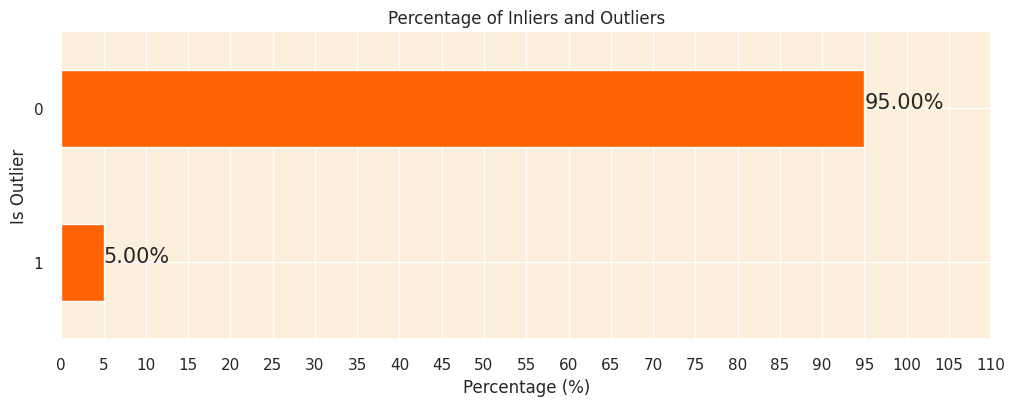

In [ ]:
# Calculate the percentage of inliers and outliers
outlier_percentage = customer_data['Is_Outlier'].value_counts(normalize=True) * 100

# Plotting the percentage of inliers and outliers
plt.figure(figsize=(12, 4))
outlier_percentage.plot(kind='barh', color='#ff6200')

# Adding the percentage labels on the bars
for index, value in enumerate(outlier_percentage):
    plt.text(value, index, f'{value:.2f}%', fontsize=15)

plt.title('Percentage of Inliers and Outliers')
plt.xticks(ticks=np.arange(0, 115, 5))
plt.xlabel('Percentage (%)')
plt.ylabel('Is Outlier')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Separate the outliers for analysis
outliers_data = customer_data[customer_data['Is_Outlier'] == 1]

# Remove the outliers from the main dataset
customer_data_cleaned = customer_data[customer_data['Is_Outlier'] == 0]

# Drop the 'Outlier_Scores' and 'Is_Outlier' columns
customer_data_cleaned = customer_data_cleaned.drop(columns=['Outlier_Scores', 'Is_Outlier'])

# Reset the index of the cleaned data
customer_data_cleaned.reset_index(drop=True, inplace=True)

In [ ]:
# Getting the number of rows in the cleaned customer dataset
customer_data_cleaned.shape[0]

15507

# **CLV analysis**



In [ ]:
customer_data_cleaned.head()

,Customer_ID,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour,GEOGRAPHY,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend
0,1,343,1,2.0,16.29,16.29,2,0.0,4,0,UK,16.29,0.0,0.0
1,2,195,2,2.0,22.77,11.385,2,87.0,2,0,Germany,11.385,5.112382,7.23
2,3,363,1,4.0,19.08,19.08,3,0.0,5,0,UK,19.08,0.0,0.0
3,4,52,2,5.0,33.29,16.645,5,0.0,1,0,UK,16.645,14.078496,19.91
4,5,179,5,14.0,248.27,49.654,2,36.5,0,0,Germany,62.0675,68.432211,-48.479


In [ ]:
# Calculate average customer lifespan in years, assuming daily transactions
avg_customer_lifespan = customer_data_cleaned['Average_Days_Between_Purchases'].mean() / 365

In [ ]:
def calculate_clv(row, avg_customer_lifespan):
    # CLV Formula: (Average Transaction Value) * (Total Transactions) * (Customer Lifespan)
    return row['Average_Transaction_Value'] * row['Total_Transactions'] * avg_customer_lifespan

In [ ]:
customer_data_cleaned['CLV'] = customer_data_cleaned.apply(lambda row: calculate_clv(row, avg_customer_lifespan), axis=1)

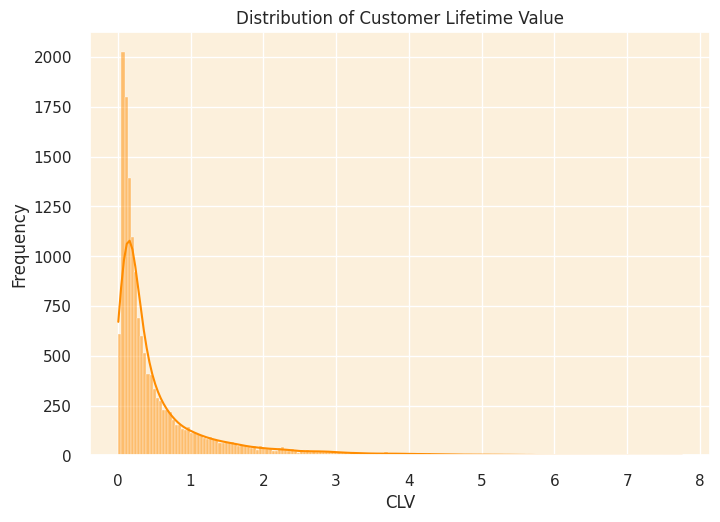

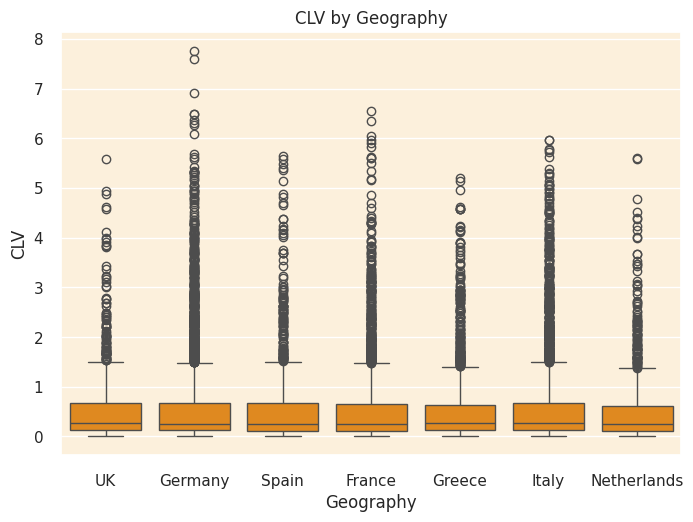

In [ ]:
# Distribution of CLV
sns.histplot(customer_data_cleaned['CLV'], kde=True)
plt.title('Distribution of Customer Lifetime Value')
plt.xlabel('CLV')
plt.ylabel('Frequency')
plt.show()

# CLV by Geography
sns.boxplot(x='GEOGRAPHY', y='CLV', data=customer_data_cleaned)
plt.title('CLV by Geography')
plt.xlabel('Geography')
plt.ylabel('CLV')
plt.show()

In [ ]:
customer_data_cleaned.columns #quick check

Index(['Customer_ID', 'Days_Since_Last_Purchase', 'Total_Transactions',
       'Total_Products_Purchased', 'Total_Spend', 'Average_Transaction_Value',
       'Unique_Products_Purchased', 'Average_Days_Between_Purchases',
       'Day_Of_Week', 'Hour', 'GEOGRAPHY', 'Monthly_Spending_Mean',
       'Monthly_Spending_Std', 'Spending_Trend', 'CLV'],
      dtype='object')

# **Clustering Preprocessing Steps**

# Correlation Analysis

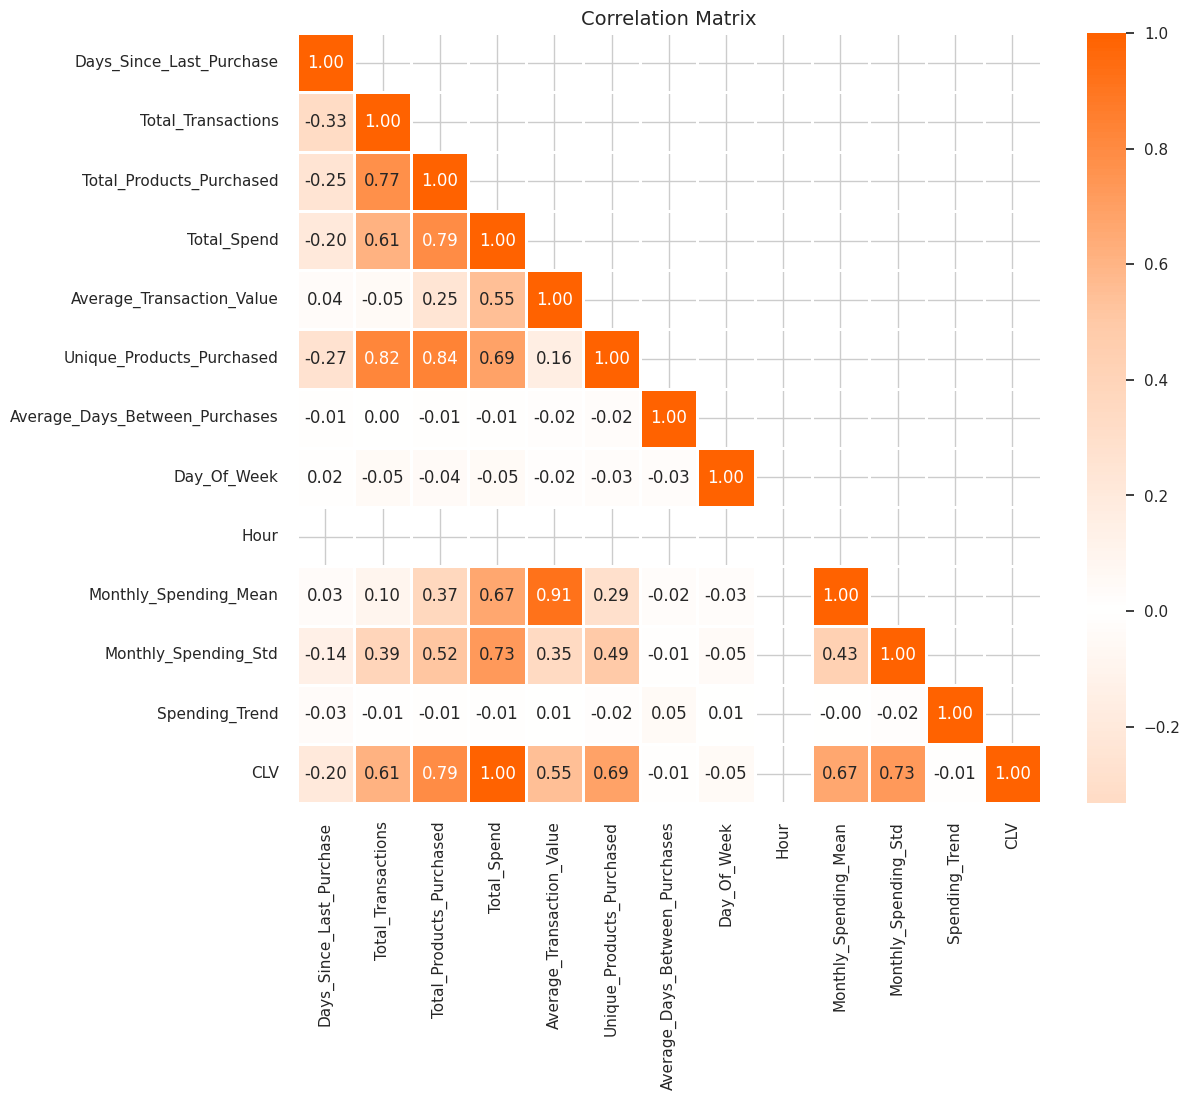

In [ ]:
# Reset background style
sns.set_style('whitegrid')

# Select only numerical columns for the correlation matrix
numerical_data = customer_data_cleaned.select_dtypes(include=[np.number])

# Calculate the correlation matrix
corr = numerical_data.corr()

# Define a custom colormap
colors = ['#ff6200', '#ffcaa8', 'white', '#ffcaa8', '#ff6200']
my_cmap = LinearSegmentedColormap.from_list('custom_map', colors, N=256)

# Create a mask to only show the lower triangle of the matrix (since it's mirrored around its top-left to bottom-right diagonal)
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask, k=1)] = True

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr, mask=mask, cmap=my_cmap, annot=True, center=0, fmt='.2f', linewidths=2)
plt.title('Correlation Matrix', fontsize=14)
plt.show()

# Feature Scaling

In [ ]:
# Initialize the StandardScaler
scaler = StandardScaler()

# List of columns that don't need to be scaled
columns_to_exclude = ['CustomerID','Day_Of_Week']

# Ensure only numeric columns are selected for scaling
numeric_columns = customer_data_cleaned.select_dtypes(include=[np.number]).columns

# List of columns that need to be scaled
columns_to_scale = numeric_columns.difference(columns_to_exclude)

# Copy the cleaned dataset
customer_data_scaled = customer_data_cleaned.copy()

# Applying the scaler to the necessary columns in the dataset
customer_data_scaled[columns_to_scale] = scaler.fit_transform(customer_data_scaled[columns_to_scale])

# Display the first few rows of the scaled data
print(customer_data_scaled.head())


  Customer_ID  Days_Since_Last_Purchase  Total_Transactions  \
0           1                  1.667899           -0.702771   
1           2                  0.380789           -0.369217   
2           3                  1.841833           -0.702771   
3           4                 -0.862838           -0.369217   
4           5                  0.241642            0.631444   

   Total_Products_Purchased  Total_Spend  Average_Transaction_Value  \
0                 -0.662514    -0.581771                  -0.394073   
1                 -0.662514    -0.531710                  -0.522937   
2                 -0.442813    -0.560217                  -0.320775   
3                 -0.332962    -0.450438                  -0.384747   
4                  0.655692     1.210378                   0.482461   

   Unique_Products_Purchased  Average_Days_Between_Purchases  Day_Of_Week  \
0                  -0.761763                       -0.075007            4   
1                  -0.761763            

# Dimensionality Reduction (PCA)

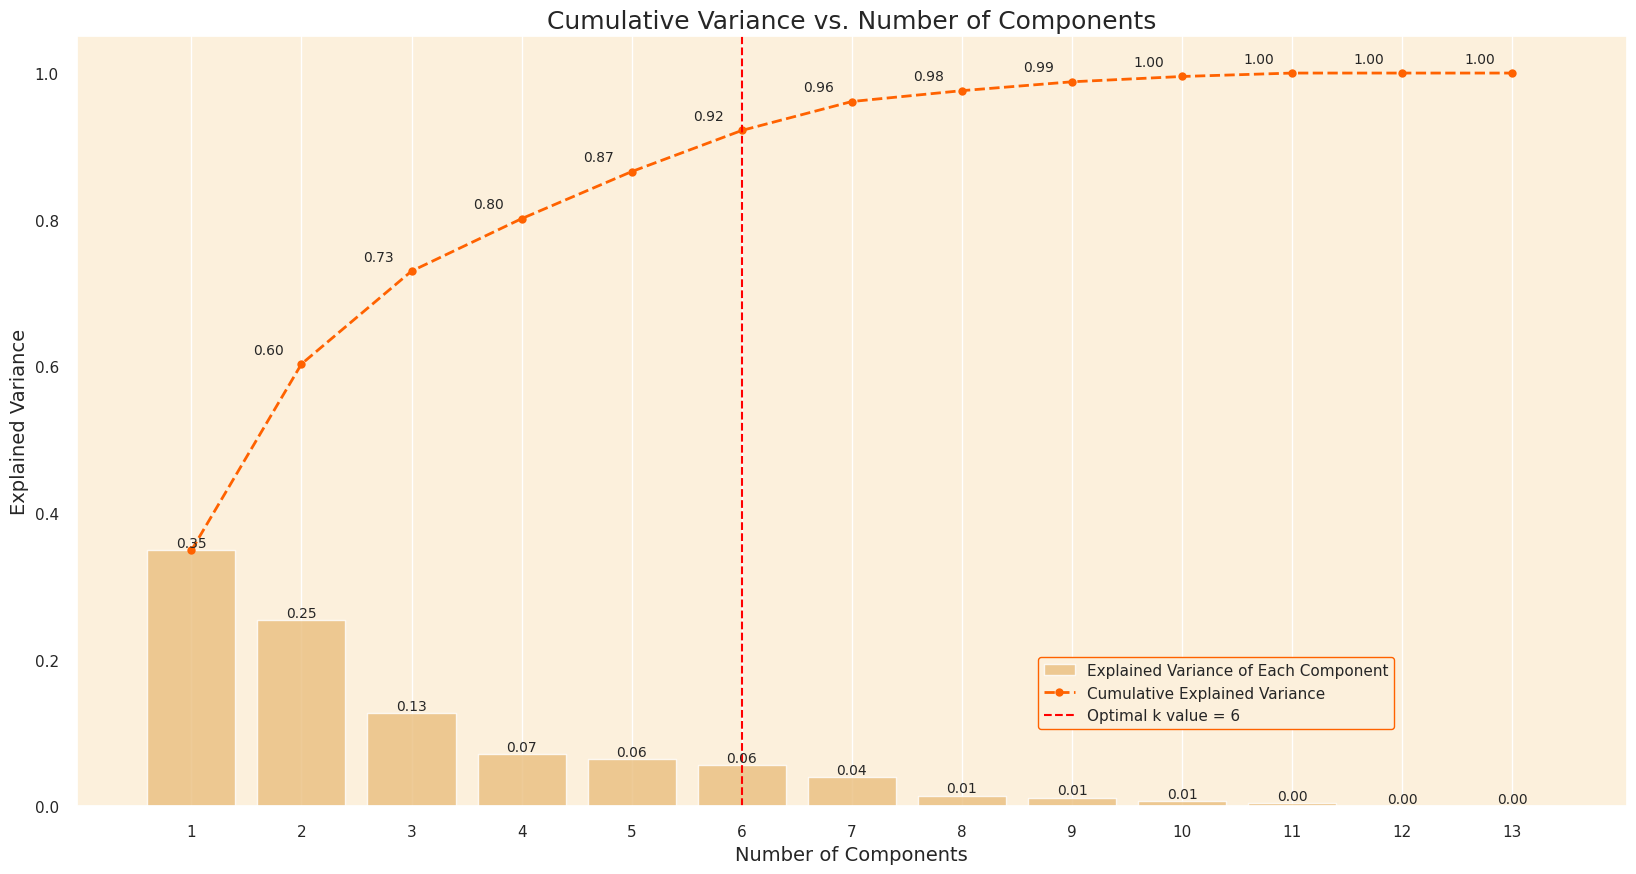

In [ ]:
# Selecting only numerical columns for PCA
numerical_columns = customer_data_scaled.select_dtypes(include=[np.number])

# Apply PCA
pca = PCA().fit(numerical_columns)

# Calculate the Cumulative Sum of the Explained Variance
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# Set the optimal k value (based on our analysis, we can choose 6)
optimal_k = 6

# Set seaborn plot style
sns.set(rc={'axes.facecolor': '#fcf0dc'}, style='darkgrid')

# Plot the cumulative explained variance against the number of components
plt.figure(figsize=(20, 10))

# Bar chart for the explained variance of each component
barplot = sns.barplot(x=list(range(1, len(cumulative_explained_variance) + 1)),
                      y=explained_variance_ratio,
                      color='#fcc36d',
                      alpha=0.8)

# Line plot for the cumulative explained variance
lineplot, = plt.plot(range(0, len(cumulative_explained_variance)), cumulative_explained_variance,
                     marker='o', linestyle='--', color='#ff6200', linewidth=2)

# Plot optimal k value line
optimal_k_line = plt.axvline(optimal_k - 1, color='red', linestyle='--', label=f'Optimal k value = {optimal_k}')

# Set labels and title
plt.xlabel('Number of Components', fontsize=14)
plt.ylabel('Explained Variance', fontsize=14)
plt.title('Cumulative Variance vs. Number of Components', fontsize=18)

# Customize ticks and legend
plt.xticks(range(0, len(cumulative_explained_variance)))
plt.legend(handles=[barplot.patches[0], lineplot, optimal_k_line],
           labels=['Explained Variance of Each Component', 'Cumulative Explained Variance', f'Optimal k value = {optimal_k}'],
           loc=(0.62, 0.1),
           frameon=True,
           framealpha=1.0,
           edgecolor='#ff6200')

# Display the variance values for both graphs on the plots
x_offset = -0.3
y_offset = 0.01
for i, (ev_ratio, cum_ev_ratio) in enumerate(zip(explained_variance_ratio, cumulative_explained_variance)):
    plt.text(i, ev_ratio, f"{ev_ratio:.2f}", ha="center", va="bottom", fontsize=10)
    if i > 0:
        plt.text(i + x_offset, cum_ev_ratio + y_offset, f"{cum_ev_ratio:.2f}", ha="center", va="bottom", fontsize=10)

plt.grid(axis='both')
plt.show()





In [ ]:
# Selecting only numerical columns for PCA
numerical_columns = customer_data_scaled.select_dtypes(include=[np.number])

# Creating a PCA object with 6 components
pca = PCA(n_components=6)

# Initializing the StandardScaler
scaler = StandardScaler()

# Fit and transform the scaler on the numerical data
scaled_numerical_columns = scaler.fit_transform(numerical_columns)

# Fitting and transforming the original data to the new PCA dataframe
customer_data_pca = pca.fit_transform(scaled_numerical_columns)

# Creating a new dataframe from the PCA dataframe, with columns labeled PC1, PC2, etc.
customer_data_pca = pd.DataFrame(customer_data_pca, columns=['PC'+str(i+1) for i in range(pca.n_components_)])

# Adding the CustomerID index back to the new PCA dataframe
customer_data_pca.index = customer_data_scaled.index

# Display the first few rows of the PCA-transformed data
print(customer_data_pca.head())


        PC1       PC2       PC3       PC4       PC5       PC6
0 -1.869337  0.618317 -0.396087  0.476782  0.405086 -1.287046
1 -1.568923 -0.118480  2.079149 -0.626614  1.716665 -0.229470
2 -1.684884  0.639834 -0.547031  0.928324  0.634613 -1.487962
3 -0.794960 -0.553299  0.616433 -0.429770 -0.828179  0.658577
4  1.962847  0.619535  0.163221 -1.958535  1.145349  0.046355


# Factor Loadings

In [ ]:
# Identify and exclude non-numeric columns (example exclusion)
numeric_columns = customer_data_scaled.select_dtypes(include=[np.number])

# Initialize PCA and StandardScaler
pca = PCA(n_components=6)
scaler = StandardScaler()

# Scale and fit_transform the numeric data
scaled_data = scaler.fit_transform(numeric_columns)

# Fit PCA on the scaled data
pca.fit(scaled_data)

# Create PCA components DataFrame
pc_df = pd.DataFrame(pca.components_.T, columns=['PC{}'.format(i+1) for i in range(pca.n_components_)],
                     index=numeric_columns.columns)

# Function to highlight top 3 absolute values in each column
def highlight_top3(column):
    top3 = column.abs().nlargest(3).index
    return ['background-color: #ffeacc' if i in top3 else '' for i in column.index]

# Apply highlighting function using .style.apply
styled_pc_df = pc_df.style.apply(highlight_top3, axis=0)

# Display styled DataFrame
styled_pc_df


,PC1,PC2,PC3,PC4,PC5,PC6
Days_Since_Last_Purchase,-0.120256,0.315544,-0.134015,-0.088977,0.137488,-0.914022
Total_Transactions,0.314378,-0.429429,-0.019271,-0.006382,0.012098,-0.132180
Total_Products_Purchased,0.383953,-0.214443,-0.023136,0.010549,0.014391,-0.144198
Total_Spend,0.425815,0.070497,0.006046,0.005788,0.014870,-0.020801
Average_Transaction_Value,0.236785,0.564464,0.039900,0.026921,-0.026184,0.188932
Unique_Products_Purchased,0.359879,-0.287539,-0.049536,0.018462,0.016039,-0.157625
Average_Days_Between_Purchases,-0.006343,-0.024243,0.692543,-0.134380,0.707400,0.010188
Day_Of_Week,-0.027056,0.009704,-0.225315,0.891263,0.391112,0.012274
Hour,-0.000000,0.000000,-0.000000,-0.000000,0.000000,0.000000
Monthly_Spending_Mean,0.289763,0.504722,0.020593,0.012515,-0.011861,0.108400


#**K-Means Clustering**

# Determining Optimal K

# Elbow method

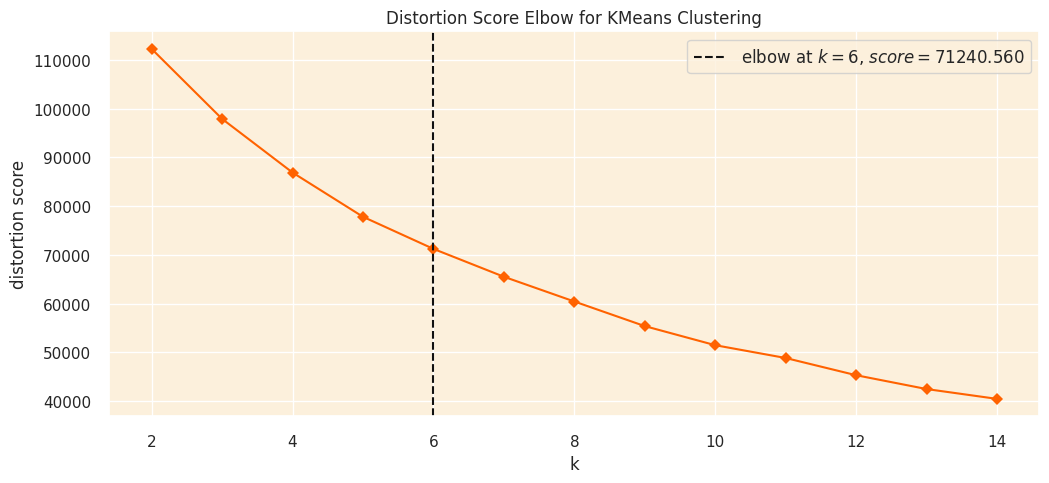

In [ ]:
# Set plot style, and background color
sns.set(style='darkgrid', rc={'axes.facecolor': '#fcf0dc'})

# Set the color palette for the plot
sns.set_palette(['#ff6200'])

# Instantiate the clustering model with the specified parameters
km = KMeans(init='k-means++', n_init=10, max_iter=100, random_state=0)

# Create a figure and axis with the desired size
fig, ax = plt.subplots(figsize=(12, 5))

# Instantiate the KElbowVisualizer with the model and range of k values, and disable the timing plot
visualizer = KElbowVisualizer(km, k=(2, 15), timings=False, ax=ax)

# Fit the data to the visualizer
visualizer.fit(customer_data_pca)

# Finalize and render the figure
visualizer.show();


# Silhouette Method

In [ ]:
def silhouette_analysis(df, start_k, stop_k, figsize=(15, 16)):
    """
    Perform Silhouette analysis for a range of k values and visualize the results.
    """

    # Set the size of the figure
    plt.figure(figsize=figsize)

    # Create a grid with (stop_k - start_k + 1) rows and 2 columns
    grid = gridspec.GridSpec(stop_k - start_k + 1, 2)

    # Assign the first plot to the first row and both columns
    first_plot = plt.subplot(grid[0, :])

    # First plot: Silhouette scores for different k values
    sns.set_palette(['darkorange'])

    silhouette_scores = []

    # Iterate through the range of k values
    for k in range(start_k, stop_k + 1):
        km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=100, random_state=0)
        km.fit(df)
        labels = km.predict(df)
        score = silhouette_score(df, labels)
        silhouette_scores.append(score)

    best_k = start_k + silhouette_scores.index(max(silhouette_scores))

    plt.plot(range(start_k, stop_k + 1), silhouette_scores, marker='o')
    plt.xticks(range(start_k, stop_k + 1))
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Silhouette score')
    plt.title('Average Silhouette Score for Different k Values', fontsize=15)

    # Add the optimal k value text to the plot
    optimal_k_text = f'The k value with the highest Silhouette score is: {best_k}'
    plt.text(10, 0.23, optimal_k_text, fontsize=12, verticalalignment='bottom',
             horizontalalignment='left', bbox=dict(facecolor='#fcc36d', edgecolor='#ff6200', boxstyle='round, pad=0.5'))


    # Second plot (subplot): Silhouette plots for each k value
    colors = sns.color_palette("bright")

    for i in range(start_k, stop_k + 1):
        km = KMeans(n_clusters=i, init='k-means++', n_init=10, max_iter=100, random_state=0)
        row_idx, col_idx = divmod(i - start_k, 2)

        # Assign the plots to the second, third, and fourth rows
        ax = plt.subplot(grid[row_idx + 1, col_idx])

        visualizer = SilhouetteVisualizer(km, colors=colors, ax=ax)
        visualizer.fit(df)

        # Add the Silhouette score text to the plot
        score = silhouette_score(df, km.labels_)
        ax.text(0.97, 0.02, f'Silhouette Score: {score:.2f}', fontsize=12, \
                ha='right', transform=ax.transAxes, color='red')

        ax.set_title(f'Silhouette Plot for {i} Clusters', fontsize=15)

    plt.tight_layout()
    plt.show()

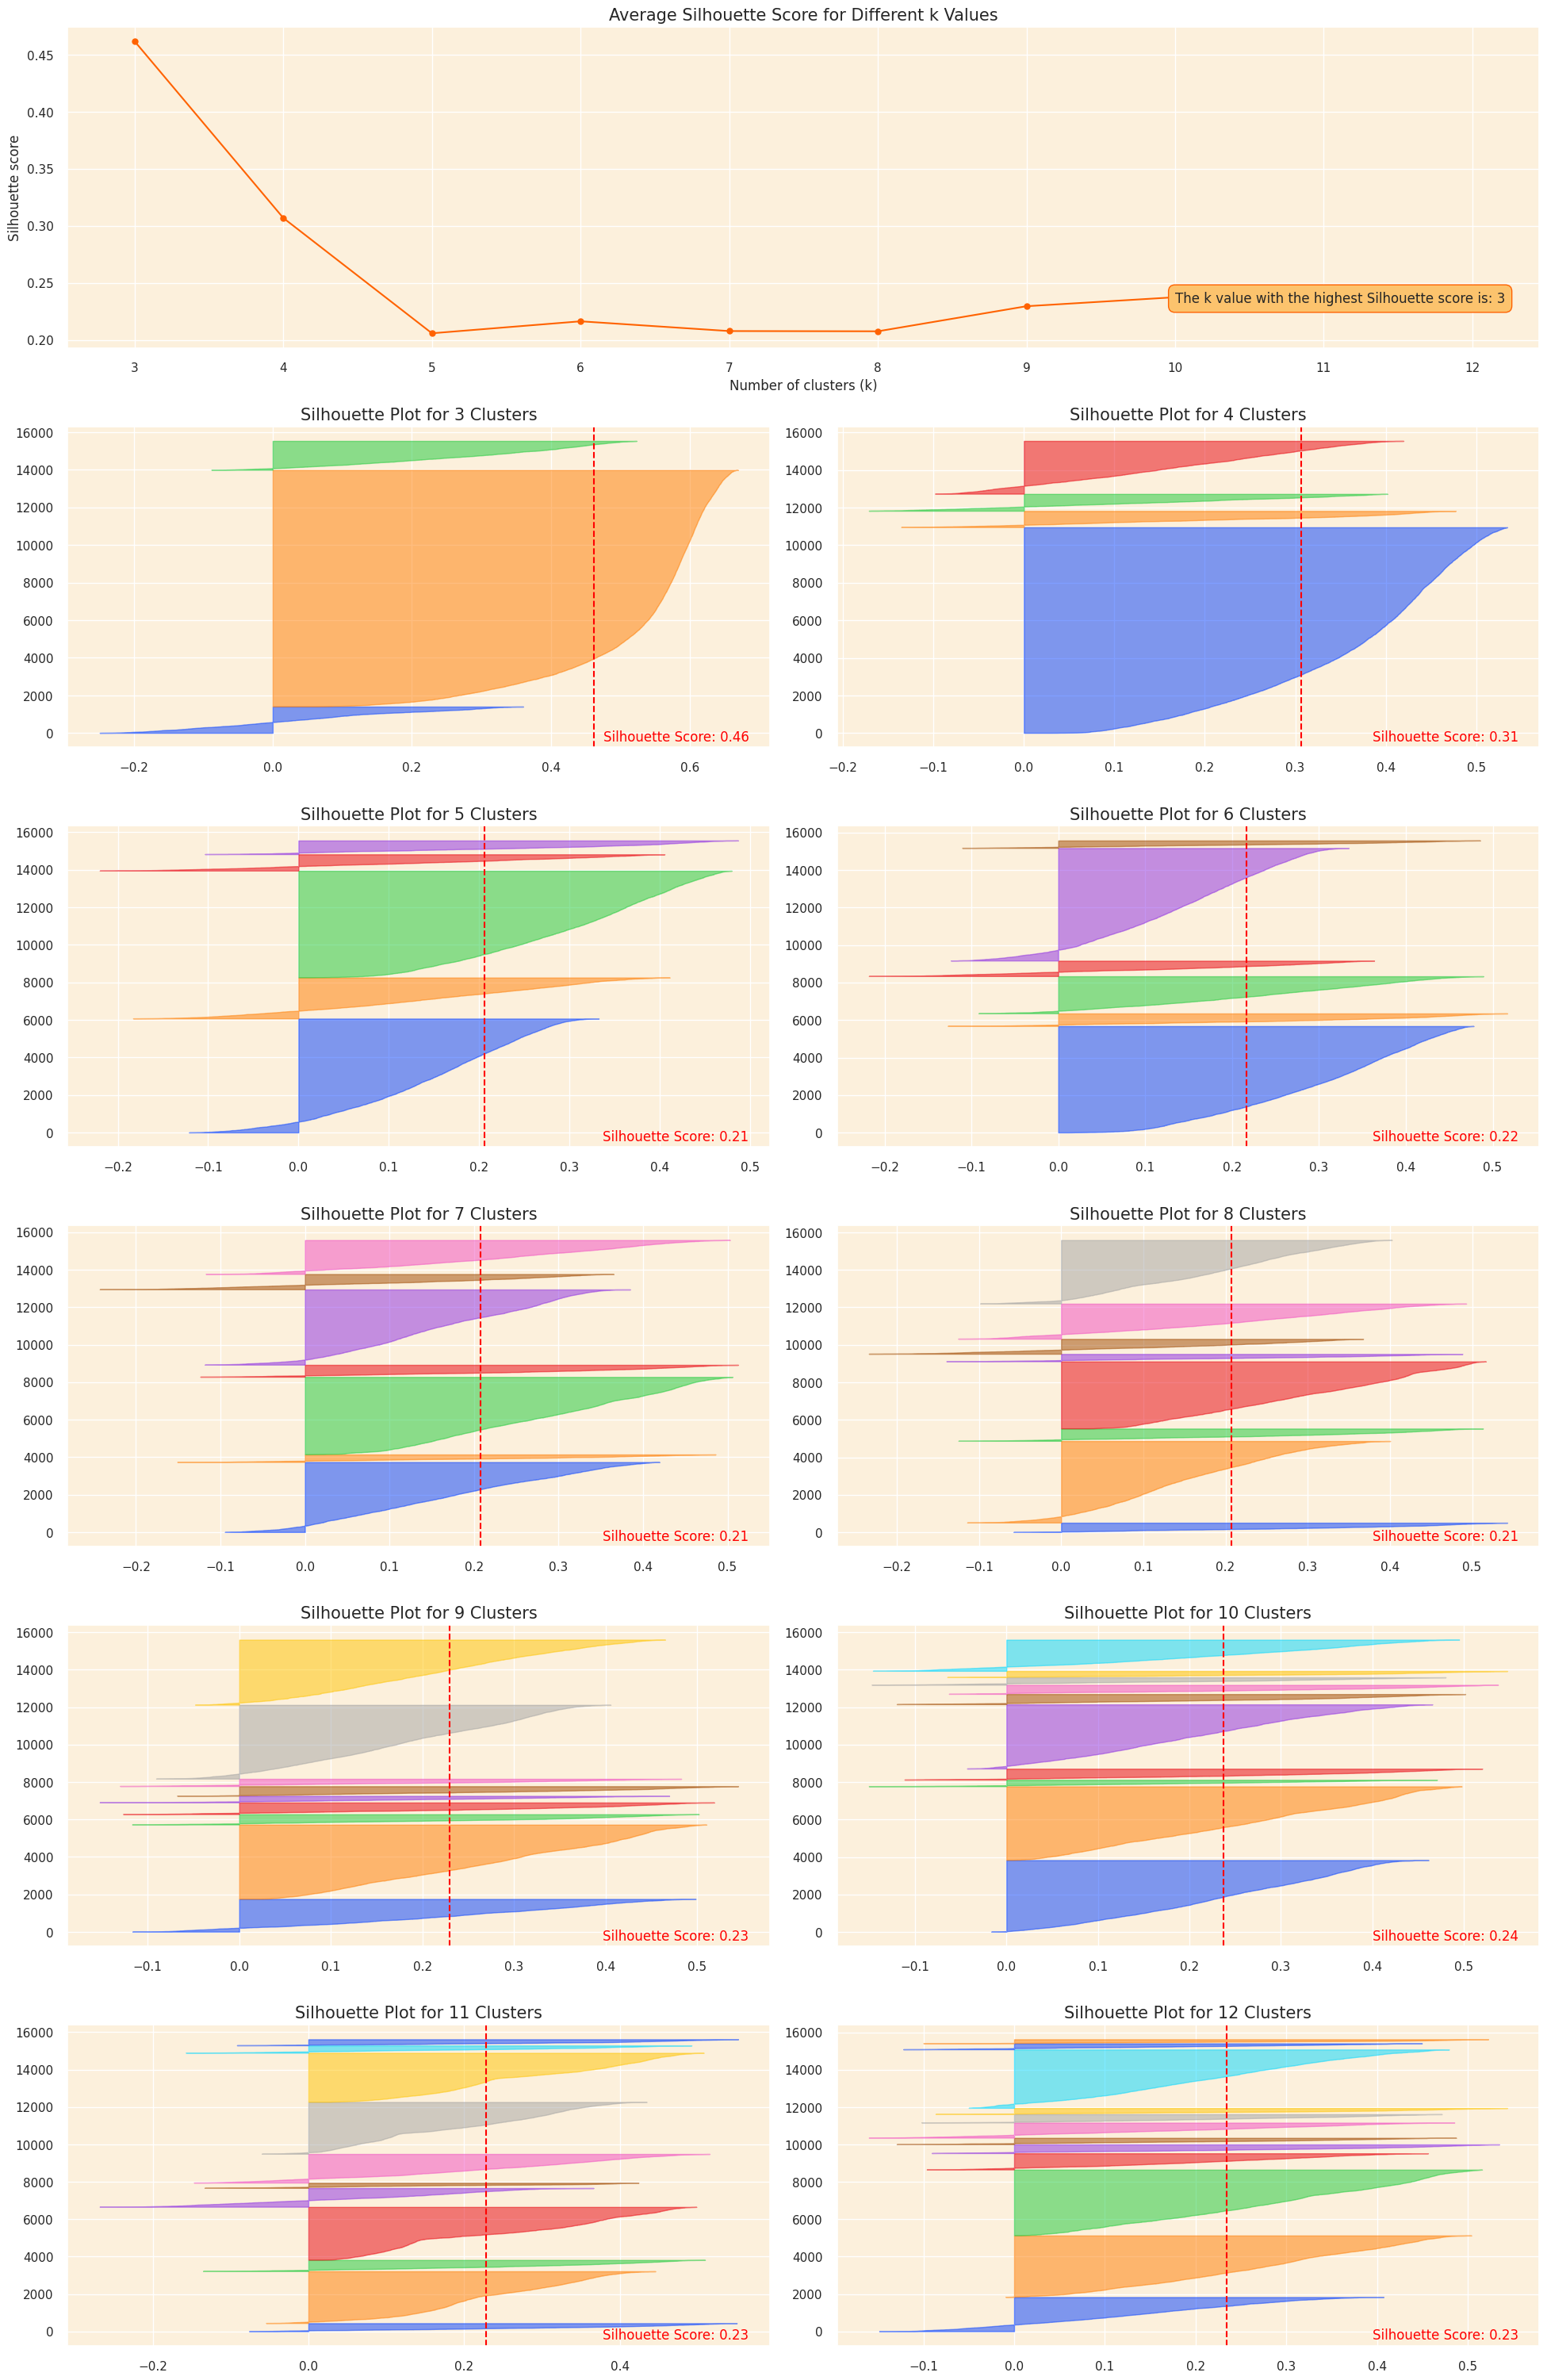

In [ ]:
silhouette_analysis(customer_data_pca, 3, 12, figsize=(20, 50))

# Unsupervised Machine Learning Clustering Model - K-means

In [ ]:
# Apply KMeans clustering using the optimal k
kmeans = KMeans(n_clusters=3, init='k-means++', n_init=10, max_iter=100, random_state=0)
kmeans.fit(customer_data_pca)

# Get the frequency of each cluster
cluster_frequencies = Counter(kmeans.labels_)

# Create a mapping from old labels to new labels based on frequency
label_mapping = {label: new_label for new_label, (label, _) in
                 enumerate(cluster_frequencies.most_common())}

# Reverse the mapping to assign labels as per your criteria
label_mapping = {v: k for k, v in {2: 1, 1: 0, 0: 2}.items()}

# Apply the mapping to get the new labels
new_labels = np.array([label_mapping[label] for label in kmeans.labels_])

# Append the new cluster labels back to the original dataset
customer_data_cleaned['cluster'] = new_labels

# Append the new cluster labels to the PCA version of the dataset
customer_data_pca['cluster'] = new_labels

In [ ]:
# Display the first few rows of the original dataframe
customer_data_cleaned.head()

,Customer_ID,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour,GEOGRAPHY,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend,CLV,cluster
0,1,343,1,2.0,16.29,16.29,2,0.0,4,0,UK,16.29,0.0,0.0,0.103467,2
1,2,195,2,2.0,22.77,11.385,2,87.0,2,0,Germany,11.385,5.112382,7.23,0.144626,2
2,3,363,1,4.0,19.08,19.08,3,0.0,5,0,UK,19.08,0.0,0.0,0.121188,2
3,4,52,2,5.0,33.29,16.645,5,0.0,1,0,UK,16.645,14.078496,19.91,0.211444,2
4,5,179,5,14.0,248.27,49.654,2,36.5,0,0,Germany,62.0675,68.432211,-48.479,1.576908,1


In [ ]:
# Setting up the color scheme for the clusters (RGB order)
colors = ['#e8000b', '#1ac938', '#023eff']

# PCA and K-Means Scatterplots

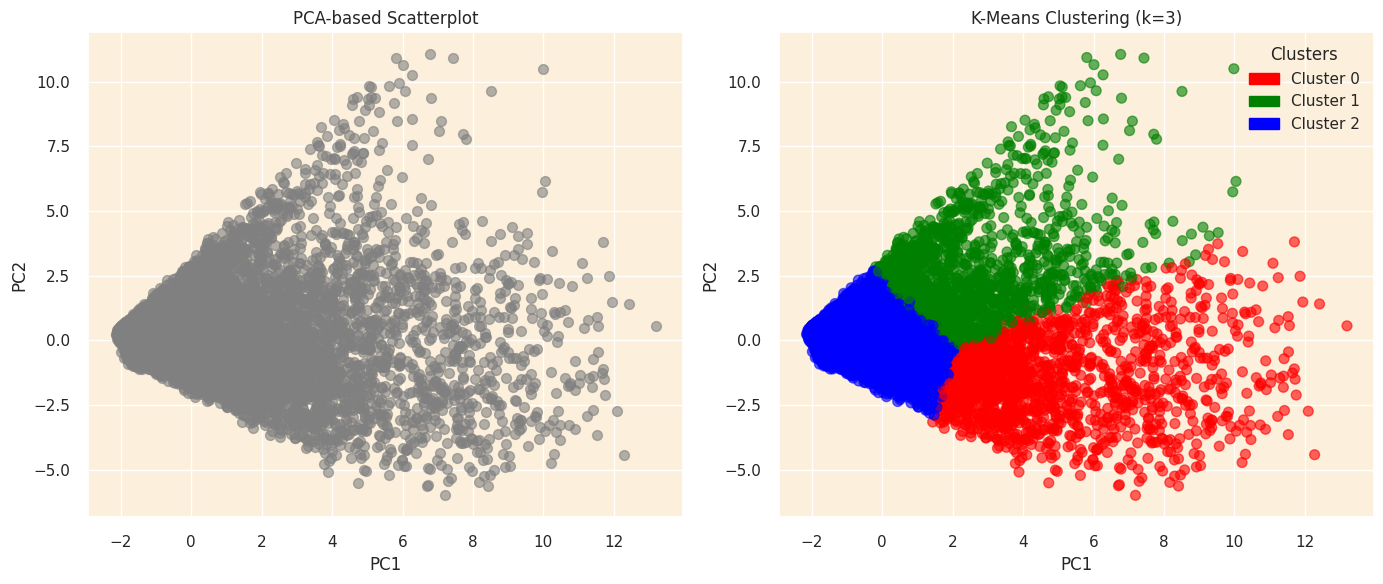

In [ ]:
# Define the custom color palette
colors = {0: 'red', 1: 'green', 2: 'blue'}

# Create a figure with two subplots side by side
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Scatterplot 1: PCA-based (original PCA components)
ax[0].scatter(customer_data_pca['PC1'], customer_data_pca['PC2'], c='gray', s=50, alpha=0.6)
ax[0].set_title('PCA-based Scatterplot')
ax[0].set_xlabel('PC1')
ax[0].set_ylabel('PC2')

# Map new_labels to corresponding colors
mapped_colors = np.array([colors[label] for label in new_labels])

# Scatterplot 2: K-Means Clustering based on PCA components
scatter = ax[1].scatter(customer_data_pca['PC1'], customer_data_pca['PC2'], c=mapped_colors, s=50, alpha=0.6)
ax[1].set_title('K-Means Clustering (k=3)')
ax[1].set_xlabel('PC1')
ax[1].set_ylabel('PC2')

# Custom legend for the clusters
import matplotlib.patches as mpatches
legend_labels = [mpatches.Patch(color=colors[i], label=f'Cluster {i}') for i in range(3)]
ax[1].legend(handles=legend_labels, title="Clusters")

# Adjust layout and display the plots
plt.tight_layout()
plt.show()

# 3D Visualization of Top Principal Components

In [ ]:
# Create separate data frames for each cluster
cluster_0 = customer_data_pca[customer_data_pca['cluster'] == 0]
cluster_1 = customer_data_pca[customer_data_pca['cluster'] == 1]
cluster_2 = customer_data_pca[customer_data_pca['cluster'] == 2]

# Create a 3D scatter plot
fig = go.Figure()

# Add data points for each cluster separately and specify the color
fig.add_trace(go.Scatter3d(x=cluster_0['PC1'], y=cluster_0['PC2'], z=cluster_0['PC3'],
                           mode='markers', marker=dict(color=colors[0], size=5, opacity=0.4), name='Cluster 0'))
fig.add_trace(go.Scatter3d(x=cluster_1['PC1'], y=cluster_1['PC2'], z=cluster_1['PC3'],
                           mode='markers', marker=dict(color=colors[1], size=5, opacity=0.4), name='Cluster 1'))
fig.add_trace(go.Scatter3d(x=cluster_2['PC1'], y=cluster_2['PC2'], z=cluster_2['PC3'],
                           mode='markers', marker=dict(color=colors[2], size=5, opacity=0.4), name='Cluster 2'))

# Set the title and layout details
fig.update_layout(
    title=dict(text='3D Visualization of Customer Clusters in PCA Space', x=0.5),
    scene=dict(
        xaxis=dict(backgroundcolor="#fcf0dc", gridcolor='white', title='PC1'),
        yaxis=dict(backgroundcolor="#fcf0dc", gridcolor='white', title='PC2'),
        zaxis=dict(backgroundcolor="#fcf0dc", gridcolor='white', title='PC3'),
    ),
    width=900,
    height=800
)

# Show the plot
fig.show()

# Cluster Distribution Visualization

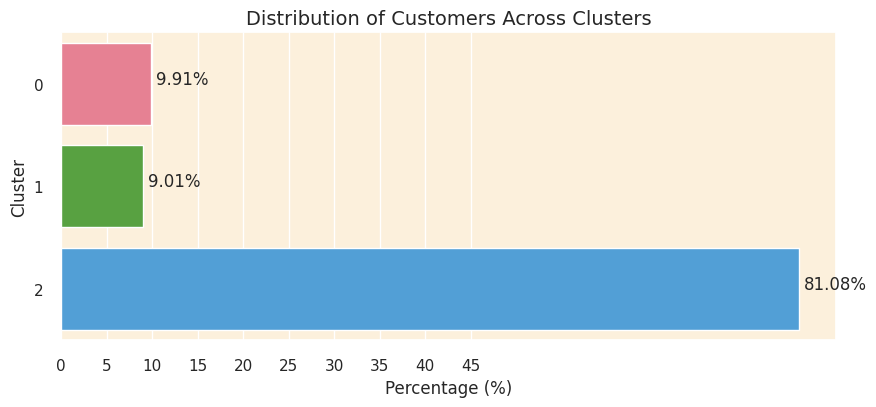

In [ ]:
# Calculate the percentage of customers in each cluster
cluster_percentage = (customer_data_pca['cluster'].value_counts(normalize=True) * 100).reset_index()
cluster_percentage.columns = ['Cluster', 'Percentage']
cluster_percentage.sort_values(by='Cluster', inplace=True)

# Define a color palette
colors = sns.color_palette("husl", len(cluster_percentage['Cluster'].unique()))

# Create a horizontal bar plot
plt.figure(figsize=(10, 4))
sns.barplot(x='Percentage', y='Cluster', data=cluster_percentage, orient='h', hue='Cluster', palette=colors, dodge=False, legend=False)

# Adding percentages on the bars
for index, value in enumerate(cluster_percentage['Percentage']):
    plt.text(value+0.5, index, f'{value:.2f}%')

plt.title('Distribution of Customers Across Clusters', fontsize=14)
plt.xticks(ticks=np.arange(0, 50, 5))
plt.xlabel('Percentage (%)')

# Show the plot
plt.show()


# Evaluation Metrics

In [ ]:
# Compute number of customers
num_observations = len(customer_data_pca)

# Separate the features and the cluster labels
X = customer_data_pca.drop('cluster', axis=1)
clusters = customer_data_pca['cluster']

# Compute the metrics
sil_score = silhouette_score(X, clusters)
calinski_score = calinski_harabasz_score(X, clusters)
davies_score = davies_bouldin_score(X, clusters)

# Create a table to display the metrics and the number of observations
table_data = [
    ["Number of Observations", num_observations],
    ["Silhouette Score", sil_score],
    ["Calinski Harabasz Score", calinski_score],
    ["Davies Bouldin Score", davies_score]
]

# Print the table
print(tabulate(table_data, headers=["Metric", "Value"], tablefmt='pretty'))

+-------------------------+--------------------+
|         Metric          |       Value        |
+-------------------------+--------------------+
| Number of Observations  |       15507        |
|    Silhouette Score     | 0.4616937792431819 |
| Calinski Harabasz Score | 5560.480003986419  |
|  Davies Bouldin Score   | 1.3703670447569032 |
+-------------------------+--------------------+


# Radar Chart Comparisons

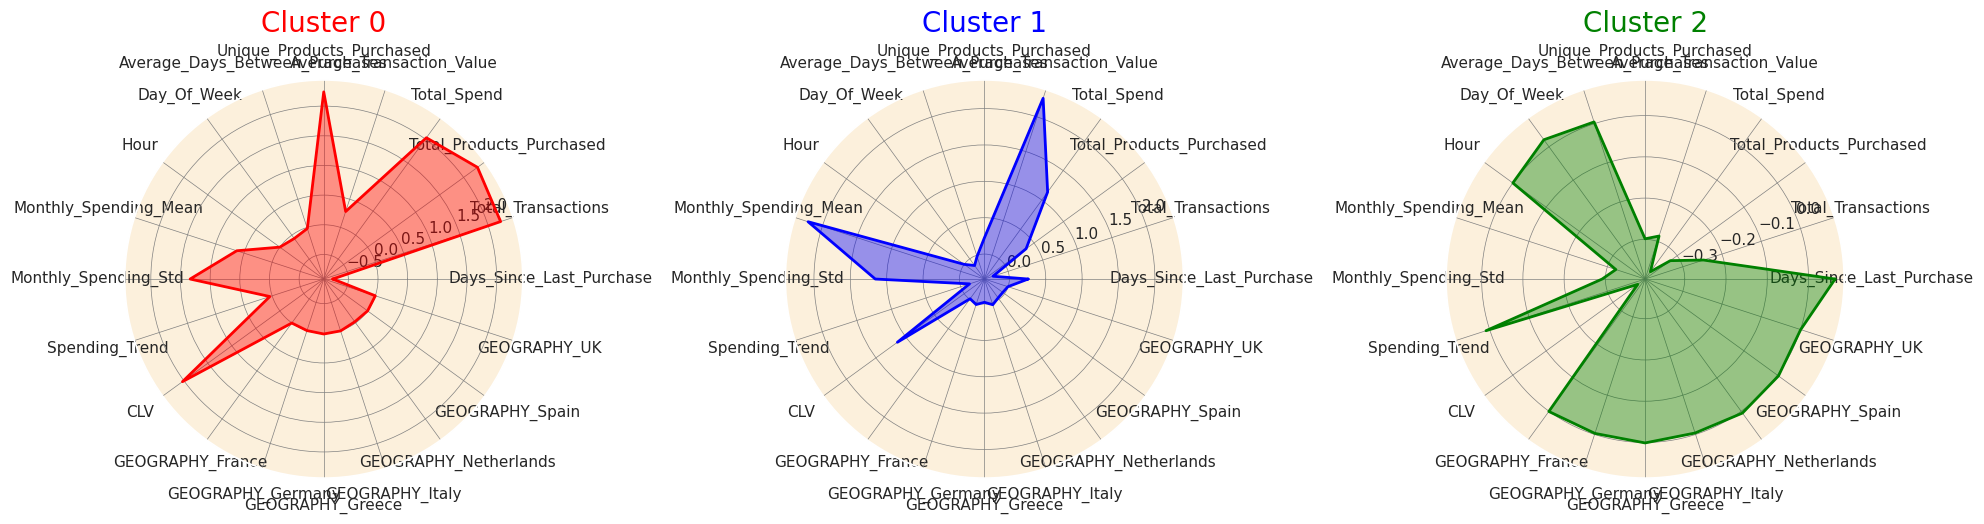

In [ ]:
# Setting 'CustomerID' column as index and assigning it to a new dataframe
df_customer = customer_data_cleaned.set_index('Customer_ID')

# Separate the features and the cluster column
features = df_customer.drop(columns=['cluster'])
clusters = df_customer['cluster']

# One-hot encode categorical variables
features_encoded = pd.get_dummies(features)

# Standardize the data
scaler = StandardScaler()
features_standardized = scaler.fit_transform(features_encoded)

# Create a new dataframe with standardized values and add the cluster column back
df_customer_standardized = pd.DataFrame(features_standardized, columns=features_encoded.columns, index=df_customer.index)
df_customer_standardized['cluster'] = clusters

# Calculate the centroids of each cluster
cluster_centroids = df_customer_standardized.groupby('cluster').mean()

# Function to create a radar chart
def create_radar_chart(ax, angles, data, color, cluster):
    # Plot the data and fill the area
    ax.fill(angles, data, color=color, alpha=0.4)
    ax.plot(angles, data, color=color, linewidth=2, linestyle='solid')

    # Add a title
    ax.set_title(f'Cluster {cluster}', size=20, color=color, y=1.1)

# Set data
labels = np.array(cluster_centroids.columns)
num_vars = len(labels)

# Compute angle of each axis
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

# The plot is circular, so we need to "complete the loop" and append the start to the end
labels = np.concatenate((labels, [labels[0]]))
angles += angles[:1]

# Define colors for each cluster
colors = ['red', 'blue', 'green']

# Initialize the figure
fig, ax = plt.subplots(figsize=(20, 10), subplot_kw=dict(polar=True), nrows=1, ncols=3)

# Create radar chart for each cluster
for i, color in enumerate(colors):
    data = cluster_centroids.loc[i].tolist()
    data += data[:1]  # Complete the loop
    create_radar_chart(ax[i], angles, data, color, i)

# Set x-ticks and labels for all subplots
for i in range(3):
    ax[i].set_xticks(angles[:-1])
    ax[i].set_xticklabels(labels[:-1])

# Add a grid
for i in range(3):
    ax[i].grid(color='grey', linewidth=0.5)

# Display the plot
plt.tight_layout()
plt.show()

# Histogram Chart Comparisons

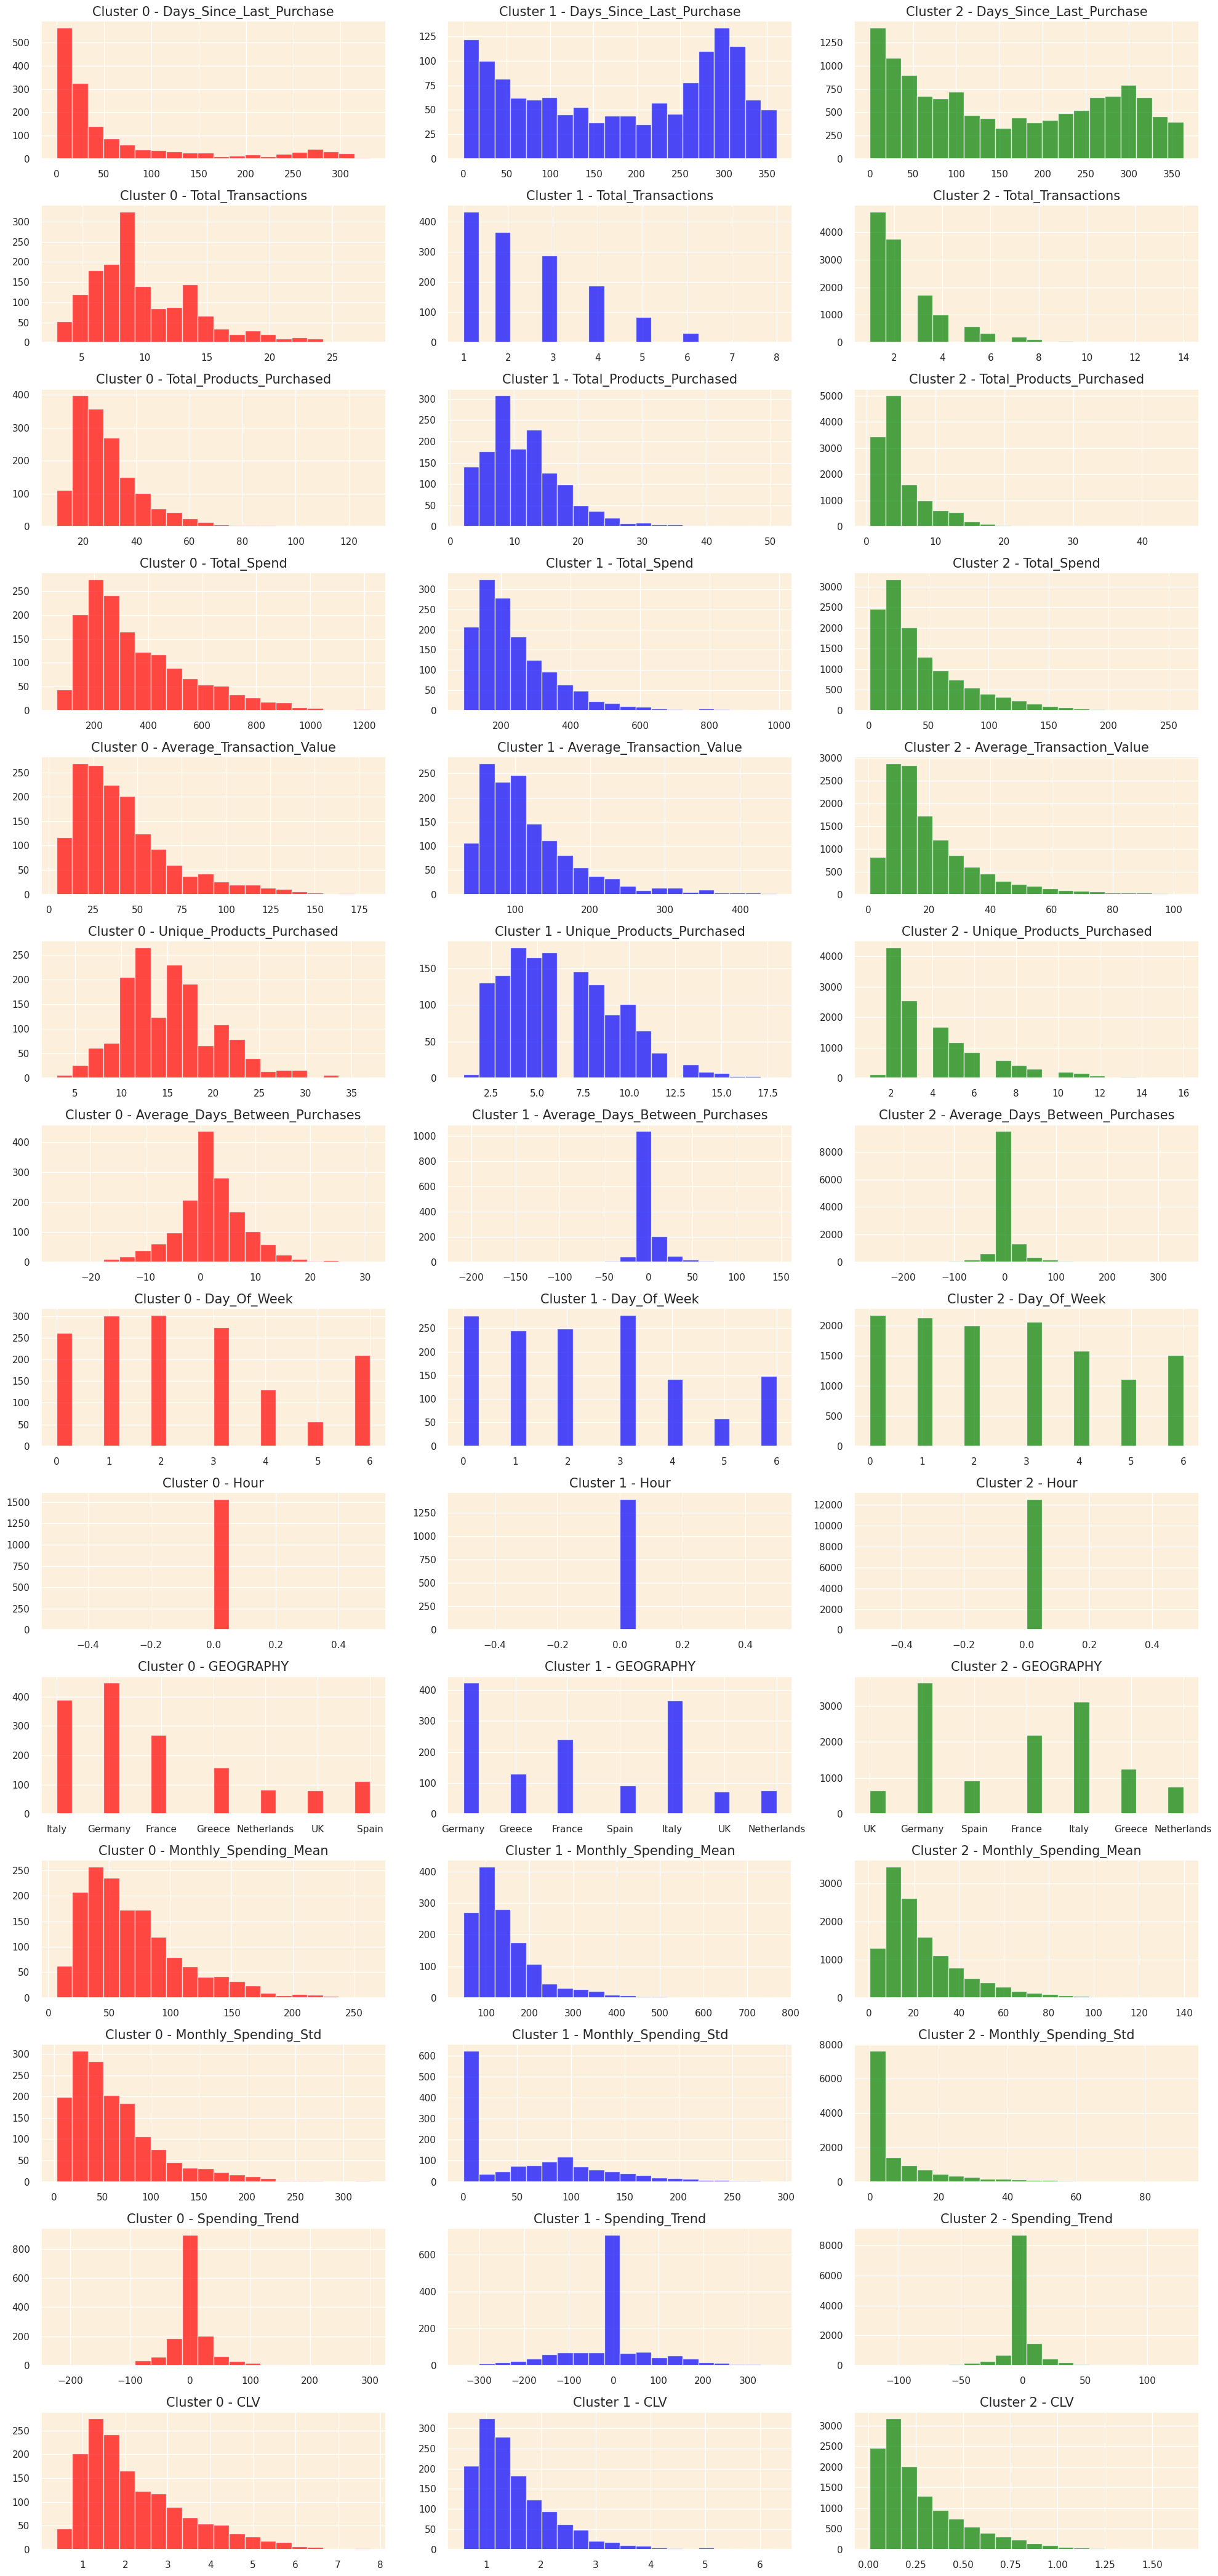

In [ ]:
# Plot histograms for each feature segmented by the clusters
features = customer_data_cleaned.columns[1:-1]
clusters = customer_data_cleaned['cluster'].unique()
clusters.sort()

# Setting up the subplots
n_rows = len(features)
n_cols = len(clusters)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 3*n_rows))

# Plotting histograms
for i, feature in enumerate(features):
    for j, cluster in enumerate(clusters):
        data = customer_data_cleaned[customer_data_cleaned['cluster'] == cluster][feature]
        axes[i, j].hist(data, bins=20, color=colors[j], edgecolor='w', alpha=0.7)
        axes[i, j].set_title(f'Cluster {cluster} - {feature}', fontsize=15)
        axes[i, j].set_xlabel('')
        axes[i, j].set_ylabel('')

# Adjusting layout to prevent overlapping
plt.tight_layout()
plt.show()

# **Summary statistics for the entire dataset**

In [ ]:
# Summary statistics for the entire dataset
overall_summary = customer_data_cleaned.describe()
print(overall_summary)

       Days_Since_Last_Purchase  Total_Transactions  Total_Products_Purchased  \
count                   15507.0             15507.0                   15507.0   
mean                 151.214484            3.106919                  8.031051   
std                  114.989973            2.998115                  9.103581   
min                         0.0                 1.0                       0.5   
25%                        40.0                 1.0                       3.0   
50%                       128.0                 2.0                       5.0   
75%                       264.0                 4.0                       9.0   
max                       363.0                28.0                     128.0   

       Total_Spend  Average_Transaction_Value  Unique_Products_Purchased  \
count      15507.0                    15507.0                    15507.0   
mean     91.595809                  31.289836                   5.341975   
std     129.446516                  38.064

In [ ]:
# Group by GEOGRAPHY and calculate summary statistics
geo_summary = customer_data_cleaned.groupby('GEOGRAPHY').describe()
print(geo_summary)

            Days_Since_Last_Purchase                                     \
                               count        mean         std  min   25%   
GEOGRAPHY                                                                 
France                        2712.0  155.169985  115.948221  0.0  43.0   
Germany                       4516.0  150.372232  115.340088  0.0  40.0   
Greece                        1539.0  148.698506  113.599913  0.0  37.0   
Italy                         3883.0  151.142158  115.428264  0.0  39.0   
Netherlands                    914.0  152.781182  116.014551  0.0  42.0   
Spain                         1133.0  148.424537  111.769089  0.0  38.0   
UK                             810.0  149.928395  113.664698  0.0  43.0   

                                 Total_Transactions            ...       CLV  \
               50%    75%    max              count      mean  ...       75%   
GEOGRAPHY                                                      ...             
France   

# Cluster descriptives summary

In [ ]:
# Group by clusters and calculate summary statistics
cluster_summary = customer_data_cleaned.groupby('cluster').describe()
print(cluster_summary)

        Days_Since_Last_Purchase                                            \
                           count        mean         std  min   25%    50%   
cluster                                                                      
0                         1537.0    63.57905    83.35055  0.0  11.0   25.0   
1                         1397.0  180.917681  114.212865  0.0  69.0  194.0   
2                        12573.0  158.627217  113.663386  0.0  49.0  142.0   

                      Total_Transactions            ... Spending_Trend  \
           75%    max              count      mean  ...            75%   
cluster                                             ...                  
0         76.0  331.0             1537.0  9.764476  ...      10.119286   
1        290.0  361.0             1397.0  2.450966  ...           8.76   
2        268.0  363.0            12573.0  2.365943  ...          0.715   

                     CLV                                                    \
        

# Revenue

In [ ]:
# Calculate total spend if it's not already present
customer_data_cleaned['Total_Spend'] = customer_data_cleaned['Average_Transaction_Value'] * customer_data_cleaned['Total_Transactions']

# Now calculate the total company revenue
total_revenue = customer_data_cleaned['Total_Spend'].sum()
print(f"Total Company Revenue: ${total_revenue}")


Total Company Revenue: $1420376.2063


In [ ]:
customer_data_cleaned['Total_Spend'] = customer_data_cleaned['Average_Transaction_Value'] * customer_data_cleaned['Total_Transactions']
total_revenue = customer_data_cleaned['Total_Spend'].sum()
customer_data_cleaned['Total_Revenue'] = total_revenue

In [ ]:
revenue_per_country = customer_data_cleaned.groupby('GEOGRAPHY')['Total_Spend'].sum().reset_index()
print(revenue_per_country)

     GEOGRAPHY  Total_Spend
0       France   243882.582
1      Germany  426711.7947
2       Greece    137444.22
3        Italy  355758.4017
4  Netherlands   78033.3067
5        Spain  104627.3278
6           UK   73918.5734


In [ ]:
# Assuming customer_data_cleaned is your DataFrame
revenue_per_cluster = customer_data_cleaned.groupby('cluster')['Total_Spend'].sum().reset_index()
print(revenue_per_cluster)

   cluster  Total_Spend
0        0  544480.5604
1        1  333298.6475
2        2  542596.9984


# **Follow-up Tableau Analysis Set-Up**

In [ ]:
df_customer_standardized
# check dataset to be exported for subsequent analysis

,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour,Monthly_Spending_Mean,...,Spending_Trend,CLV,GEOGRAPHY_France,GEOGRAPHY_Germany,GEOGRAPHY_Greece,GEOGRAPHY_Italy,GEOGRAPHY_Netherlands,GEOGRAPHY_Spain,GEOGRAPHY_UK,cluster
Customer_ID,,,,,,,,,,,,,,,,,,,,,
1,1.667899,-0.702771,-0.662514,-0.581771,-0.394073,-0.761763,-0.075007,0.716509,0.0,-0.484840,...,0.003611,-0.581771,-0.460389,-0.641000,-0.331934,-0.577971,-0.250265,-0.280754,4.259630,2
2,0.380789,-0.369217,-0.662514,-0.531710,-0.522937,-0.761763,2.739797,-0.310187,0.0,-0.588963,...,0.207932,-0.531710,-0.460389,1.560061,-0.331934,-0.577971,-0.250265,-0.280754,-0.234762,2
3,1.841833,-0.702771,-0.442813,-0.560217,-0.320775,-0.533825,-0.075007,1.229857,0.0,-0.425614,...,0.003611,-0.560217,-0.460389,-0.641000,-0.331934,-0.577971,-0.250265,-0.280754,4.259630,2
4,-0.862838,-0.369217,-0.332962,-0.450438,-0.384747,-0.077949,-0.075007,-0.823535,0.0,-0.477304,...,0.566270,-0.450438,-0.460389,-0.641000,-0.331934,-0.577971,-0.250265,-0.280754,4.259630,2
5,0.241642,0.631444,0.655692,1.210378,0.482461,-0.761763,1.105916,-1.336883,0.0,0.486926,...,-1.366412,1.210378,-0.460389,1.560061,-0.331934,-0.577971,-0.250265,-0.280754,-0.234762,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22619,-1.080255,-0.702771,-0.662514,-0.659875,-0.659682,-0.761763,-0.075007,1.229857,0.0,-0.699455,...,0.003611,-0.659875,-0.460389,-0.641000,-0.331934,-0.577971,-0.250265,3.561836,-0.234762,2
22621,-1.132435,-0.702771,-0.552663,-0.574818,-0.370429,-0.761763,-0.075007,0.716509,0.0,-0.465735,...,0.003611,-0.574818,-0.460389,-0.641000,-0.331934,-0.577971,3.995758,-0.280754,-0.234762,2
22623,-1.228099,-0.702771,-0.552663,1.037328,5.111981,-0.761763,-0.075007,-0.823535,0.0,3.964131,...,0.003611,1.037328,-0.460389,-0.641000,-0.331934,-0.577971,-0.250265,3.561836,-0.234762,1


In [ ]:
# simplify the file name:

Final_df_capstone = df_customer_standardized

In [ ]:
# Save the modified DataFrame as an Excel and CSV file
Final_df_capstone.to_excel('Final_df_capstone.xlsx', index=True)
Final_df_capstone.to_csv('Final_df_capstone.csv', index=True)

# Download the Excel file
files.download('Final_df_capstone.xlsx')

# Download the CSV file
files.download('Final_df_capstone.csv')

print("Downloaded as 'Final_df_capstone.xlsx' and 'Final_df_capstone.csv'.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded as 'Final_df_capstone.xlsx' and 'Final_df_capstone.csv'.
